# Exam #2 - Take home
## Math 742 - Mathematical Statistics
## 2026-03-27
## David Cortes
**Integrity Statement:** I have read and understand the exam integrity statement.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(3252026)

---
## Problem 6 (10 points) — Fisher Information, CRLB, and Efficiency

Let $X_1, \ldots, X_n$ be iid $\text{Poisson}(\lambda)$, with $n = 50$ and $\lambda = 4$.

The MLE is $\hat{\lambda} = \bar{X}$.


### Part (a): Simulation Study

In [18]:
# Parameters
n_sim_6 = 50000
n_6 = 50
lam_true = 4

# Simulate 50,000 datasets, compute lambda_hat = X_bar for each
sim_data_6 = np.random.poisson(lam=lam_true, size=(n_sim_6, n_6))
lambda_hat = sim_data_6.mean(axis=1)

# Empirical results
emp_mean_6 = lambda_hat.mean()
emp_bias_6 = emp_mean_6 - lam_true
emp_var_6 = lambda_hat.var(ddof=0)

print(f"Empirical mean of lambda_hat:     {emp_mean_6:.6f}")
print(f"True lambda:                      {lam_true}")
print(f"Empirical bias:                   {emp_bias_6:.6f}")
print(f"Empirical variance:               {emp_var_6:.6f}")
print(f"Expected variance (lambda/n):     {lam_true / n_6:.6f}")

Empirical mean of lambda_hat:     3.996858
True lambda:                      4
Empirical bias:                   -0.003142
Empirical variance:               0.081027
Expected variance (lambda/n):     0.080000


The empirical mean is very close to $\lambda = 4$, confirming that $\hat{\lambda} = \bar{X}$ is unbiased.
The empirical bias is near zero, and the empirical variance is close to $\lambda/n = 4/50 = 0.08$.

### Part (b): Fisher Information and CRLB

For one observation $X \sim \text{Poisson}(\lambda)$, the log-likelihood is

$$\log f(x|\lambda) = -\lambda + x \log \lambda - \log(x!)$$

Taking the derivative gives the score: $\frac{\partial}{\partial \lambda} \log f = -1 + x/\lambda$.

The Fisher information for one observation is $I_1(\lambda) = \text{Var}(X)/\lambda^2 = 1/\lambda$.

For the full sample of $n$ iid observations:

$$I_n(\lambda) = n \cdot I_1(\lambda) = \frac{n}{\lambda}$$

So the CRLB for any unbiased estimator of $\lambda$ is

$$\text{Var}(\hat{\lambda}) \geq \frac{1}{I_n(\lambda)} = \frac{\lambda}{n}$$

In [19]:
# Fisher information
I_1 = 1 / lam_true
I_n = n_6 / lam_true
CRLB = 1 / I_n  # = lambda / n

print(f"Fisher information (one obs):   I_1(lambda) = 1/lambda = {I_1:.4f}")
print(f"Fisher information (full sample): I_n(lambda) = n/lambda = {I_n:.4f}")
print(f"CRLB = lambda/n = {CRLB:.4f}")
print(f"Empirical variance =             {emp_var_6:.4f}")
print(f"\nThe empirical variance ({emp_var_6:.4f}) is very close to the CRLB ({CRLB:.4f}).")
print("This shows that the MLE (X_bar) is efficient — it achieves the CRLB.")
print("This is expected since the Poisson is an exponential family and X_bar is the MLE.")

Fisher information (one obs):   I_1(lambda) = 1/lambda = 0.2500
Fisher information (full sample): I_n(lambda) = n/lambda = 12.5000
CRLB = lambda/n = 0.0800
Empirical variance =             0.0810

The empirical variance (0.0810) is very close to the CRLB (0.0800).
This shows that the MLE (X_bar) is efficient — it achieves the CRLB.
This is expected since the Poisson is an exponential family and X_bar is the MLE.


### Part (c): Asymptotic Normality Plot

By the asymptotic theory of MLEs, $\hat{\lambda}$ is approximately distributed as

$$\hat{\lambda} \sim N\left(\lambda, \frac{\lambda}{n}\right) = N(4, 0.08)$$

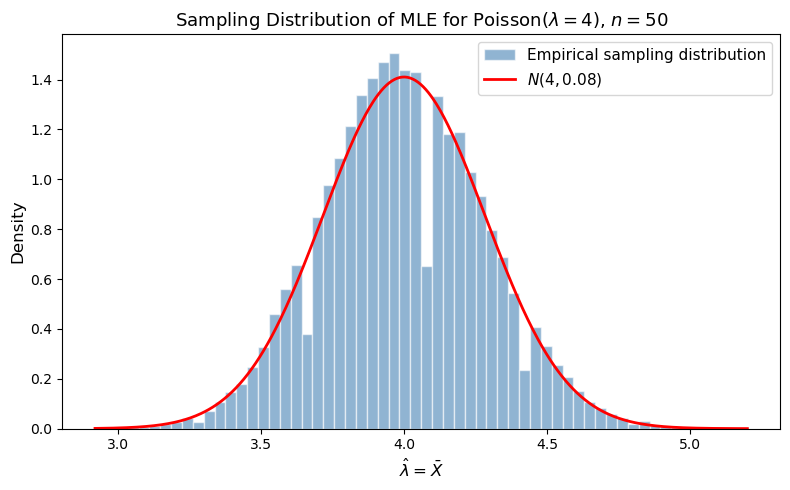

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

# Empirical density
ax.hist(lambda_hat, bins=60, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='Empirical sampling distribution')

# Asymptotic normal overlay
x_grid = np.linspace(lambda_hat.min(), lambda_hat.max(), 500)
asymp_mean = lam_true
asymp_var = lam_true / n_6
normal_pdf = stats.norm.pdf(x_grid, loc=asymp_mean, scale=np.sqrt(asymp_var))
ax.plot(x_grid, normal_pdf, 'r-', lw=2, label=f'$N({asymp_mean}, {asymp_var})$')

ax.set_xlabel(r'$\hat{\lambda} = \bar{X}$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sampling Distribution of MLE for Poisson($\lambda=4$), $n=50$', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Comments:**

- The normal approximation fits the empirical sampling distribution very well. With $n = 50$, the sample size is large enough for the CLT / asymptotic normality of the MLE to provide an excellent approximation.
- The estimator $\hat{\lambda} = \bar{X}$ appears efficient: its empirical variance matches the CRLB $\lambda/n = 0.08$ almost exactly.

---
## Problem 7 (10 points) — Delta Method and Asymptotic Approximation

Let $X_1, \ldots, X_n$ be iid $N(\mu, \sigma^2)$, with $\mu = 1$, $\sigma^2 = 4$, $n = 100$.

Let $\hat{\mu} = \bar{X}$ and $g(\mu) = e^{\mu}$. We study the estimator $g(\hat{\mu}) = e^{\bar{X}}$.


### Part (a): Delta Method Derivation

We know that $\bar{X} \sim N(\mu, \sigma^2/n)$ approximately.

The **Delta Method** states: if $\sqrt{n}(\hat{\theta} - \theta) \to N(0, \sigma^2)$ in distribution, then for a differentiable function $g$:

$$\sqrt{n}\big(g(\hat{\theta}) - g(\theta)\big) \to N\big(0, [g'(\theta)]^2 \sigma^2\big)$$

Equivalently:

$$g(\bar{X}) \sim N\left(g(\mu),\; [g'(\mu)]^2 \cdot \frac{\sigma^2}{n}\right)$$

Since $g(\mu) = e^{\mu}$ and $g'(\mu) = e^{\mu}$:

$$e^{\bar{X}} \sim N\left(e^{\mu},\; e^{2\mu} \cdot \frac{\sigma^2}{n}\right)$$

Plugging in $\mu = 1$, $\sigma^2 = 4$, $n = 100$:

- **Asymptotic mean:** $e^1 = e \approx 2.7183$
- **Asymptotic variance:** $e^{2} \cdot \frac{4}{100} = \frac{4e^2}{100} \approx 0.2953$

So the final result is:

$$e^{\bar{X}} \sim N\left(e,\; \frac{4e^2}{100}\right) \approx N(2.7183,\; 0.2953)$$

### Part (b): Simulation Study

In [21]:
# Parameters
n_sim_7 = 100000
n_7 = 100
mu_true = 1
sigma2_true = 4

# Simulate 100,000 datasets
sim_data_7 = np.random.normal(loc=mu_true, scale=np.sqrt(sigma2_true), size=(n_sim_7, n_7))
xbar_7 = sim_data_7.mean(axis=1)
g_hat = np.exp(xbar_7)  # e^{X_bar}

# Empirical results
g_true = np.exp(mu_true)
emp_mean_7 = g_hat.mean()
emp_bias_7 = emp_mean_7 - g_true
emp_var_7 = g_hat.var(ddof=0)

# Delta method predictions
delta_mean = g_true
delta_var = np.exp(2 * mu_true) * sigma2_true / n_7

print("=== Empirical Results ===")
print(f"Empirical mean of e^Xbar:        {emp_mean_7:.6f}")
print(f"True g(mu) = e^1:                {g_true:.6f}")
print(f"Empirical bias:                  {emp_bias_7:.6f}")
print(f"Empirical variance:              {emp_var_7:.6f}")
print()
print("=== Delta Method Predictions ===")
print(f"Asymptotic mean:                 {delta_mean:.6f}")
print(f"Asymptotic variance (4e^2/100):  {delta_var:.6f}")
print()
print(f"The empirical variance ({emp_var_7:.4f}) is close to the Delta Method")
print(f"approximation ({delta_var:.4f}).")
print(f"\nThe small positive bias ({emp_bias_7:.4f}) is due to Jensen's inequality:")
print(f"since e^x is convex, E[e^Xbar] > e^(E[Xbar]) = e^mu.")

=== Empirical Results ===
Empirical mean of e^Xbar:        2.772342
True g(mu) = e^1:                2.718282
Empirical bias:                  0.054061
Empirical variance:              0.314425

=== Delta Method Predictions ===
Asymptotic mean:                 2.718282
Asymptotic variance (4e^2/100):  0.295562

The empirical variance (0.3144) is close to the Delta Method
approximation (0.2956).

The small positive bias (0.0541) is due to Jensen's inequality:
since e^x is convex, E[e^Xbar] > e^(E[Xbar]) = e^mu.


### Part (c): Plot with Normal Overlay

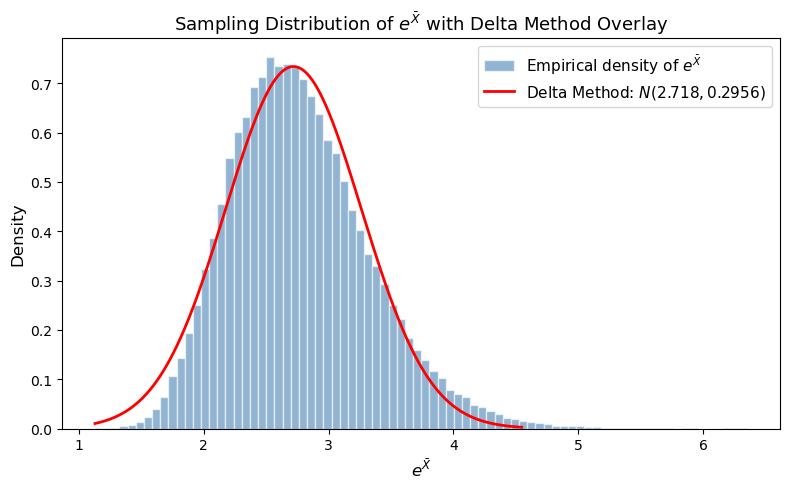

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

# Empirical density
ax.hist(g_hat, bins=80, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label=r'Empirical density of $e^{\bar{X}}$')

# Delta method normal overlay
x_grid_7 = np.linspace(g_hat.min(), np.percentile(g_hat, 99.5), 500)
normal_pdf_7 = stats.norm.pdf(x_grid_7, loc=delta_mean, scale=np.sqrt(delta_var))
ax.plot(x_grid_7, normal_pdf_7, 'r-', lw=2,
        label=f'Delta Method: $N({delta_mean:.3f}, {delta_var:.4f})$')

ax.set_xlabel(r'$e^{\bar{X}}$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(r'Sampling Distribution of $e^{\bar{X}}$ with Delta Method Overlay', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Comments:**

- **Shape of the sampling distribution:** The empirical distribution is approximately normal but exhibits a slight right skew. This is because $e^x$ is a convex, nonlinear transformation.

- **Whether the normal approximation is reasonable:** Overall, the Delta Method normal approximation captures the center and spread of the distribution well. It is a reasonable approximation for $n = 100$, although the right tail of the empirical distribution extends slightly further than the normal overlay suggests.

- **Why nonlinear transformations introduce skewness:** Even though $\bar{X}$ itself is exactly $N(\mu, \sigma^2/n)$ (since the data are normal), applying the convex function $g(x) = e^x$ "stretches" the right tail more than the left. By Jensen's inequality, $E[e^{\bar{X}}] > e^{E[\bar{X}]} = e^{\mu}$, which explains the positive bias observed in the simulation. The Delta Method is a first-order (linear) approximation and does not capture this curvature-induced skewness.

---
## Problem 8 (10 points) — Hypothesis Testing, Power, and Consistency

Let $X_1, \ldots, X_n$ be iid $N(\mu, 1)$.

We test $H_0: \mu = 0$ versus $H_1: \mu = 0.5$.


### Part (a): LRT and Neyman–Pearson Argument

We apply the **likelihood ratio test** framework (Lecture 19). The likelihood for $n$ iid $N(\mu, 1)$ observations is:

$$L(\mu | \mathbf{x}) = (2\pi)^{-n/2} \exp\left(-\frac{1}{2}\sum_{j=1}^n (x_j - \mu)^2\right)$$

The likelihood ratio is:

$$\Lambda(\mathbf{x}) = \frac{L(\mu_0 | \mathbf{x})}{L(\mu_1 | \mathbf{x})} = \frac{L(0 | \mathbf{x})}{L(0.5 | \mathbf{x})}$$

Taking logarithms (with $\sigma^2 = 1$):

$$\log \Lambda(\mathbf{x}) = -\frac{1}{2}\left[\sum(x_j - \mu_0)^2 - \sum(x_j - \mu_1)^2\right]$$

Expanding the difference of squared sums:

$$\sum(x_j - \mu_0)^2 - \sum(x_j - \mu_1)^2 = n(\mu_1 - \mu_0)\left[2\bar{X} - (\mu_1 + \mu_0)\right]$$

Substituting back:

$$\log \Lambda(\mathbf{x}) = -\frac{n(\mu_1 - \mu_0)}{2}\left[2\bar{X} - (\mu_1 + \mu_0)\right]$$

This is a **linear function** of $\bar{X}$ with negative slope (since $\mu_1 - \mu_0 = 0.5 > 0$), so the log likelihood ratio is a **decreasing** function of $\bar{X}$.

By the **Neyman–Pearson Lemma**, the most powerful level-$\alpha$ test rejects $H_0$ when $\Lambda(\mathbf{x}) \leq k$. Since $\log \Lambda$ decreases in $\bar{X}$, this is equivalent to:

$$\text{Reject } H_0 \text{ when } \bar{X} \geq c$$

for some constant $c$ chosen so that $P_{\mu_0}(\bar{X} \geq c) = \alpha$.

**Intuition:** Large values of $\bar{X}$ provide evidence in favor of $H_1: \mu = 0.5$ over $H_0: \mu = 0$, because the data are more likely when the mean is shifted to the right. The Neyman–Pearson Lemma guarantees that no other level-$\alpha$ test has higher power against $\mu = 0.5$ than this one — this is the **most powerful** test for this simple-vs-simple testing problem.

### Part (b): Power Estimation via Simulation

For a level $\alpha = 0.05$ one-sided test, we reject $H_0$ when:

$$\bar{X} > z_{0.05} \cdot \frac{1}{\sqrt{n}} = \frac{1.645}{\sqrt{n}}$$

Under $H_1$ ($\mu = 0.5$): $\bar{X} \sim N(0.5, 1/n)$.

In [23]:
# Parameters
n_sim_8 = 50000
alpha = 0.05
mu_0 = 0
mu_1 = 0.5
sigma = 1  # known
z_alpha = stats.norm.ppf(1 - alpha)  # 1.645

sample_sizes = [10, 25, 50, 100]
sim_power = []
theo_power = []

print(f"z_alpha = {z_alpha:.4f}")
print(f"{'n':>5}  {'Critical value':>14}  {'Simulated Power':>16}  {'Theoretical Power':>18}")
print("-" * 60)

for n_i in sample_sizes:
    # Critical value: reject if X_bar > c
    c = z_alpha * sigma / np.sqrt(n_i)
    
    # Simulate under H1: mu = 0.5
    xbar_sim = np.random.normal(loc=mu_1, scale=sigma / np.sqrt(n_i), size=n_sim_8)
    power_est = np.mean(xbar_sim > c)
    sim_power.append(power_est)
    
    # Theoretical power: P(X_bar > c | mu = 0.5)
    # = P(Z > (c - 0.5) / (1/sqrt(n))) = P(Z > z_alpha - 0.5*sqrt(n))
    power_theo = 1 - stats.norm.cdf(z_alpha - mu_1 * np.sqrt(n_i))
    theo_power.append(power_theo)
    
    print(f"{n_i:>5}  {c:>14.4f}  {power_est:>16.4f}  {power_theo:>18.4f}")

z_alpha = 1.6449
    n  Critical value   Simulated Power   Theoretical Power
------------------------------------------------------------
   10          0.5201            0.4717              0.4746
   25          0.3290            0.8061              0.8038
   50          0.2326            0.9700              0.9707
  100          0.1645            0.9998              0.9996


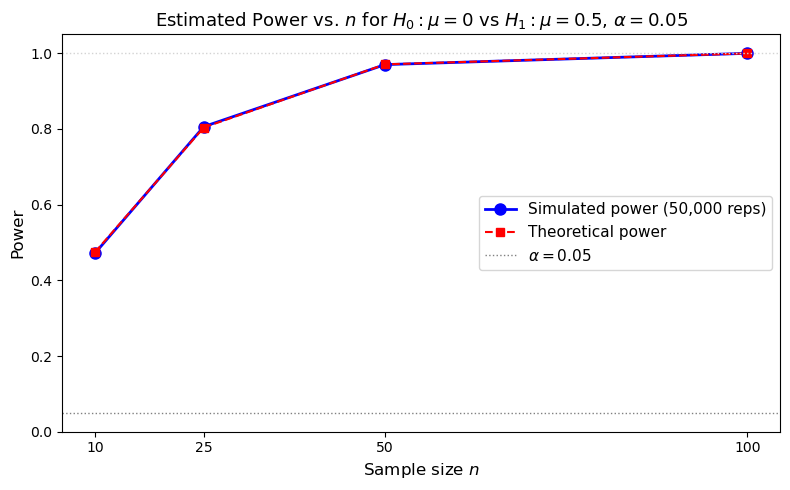

In [24]:
# Plot power vs n
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sample_sizes, sim_power, 'bo-', ms=8, lw=2, label='Simulated power (50,000 reps)')
ax.plot(sample_sizes, theo_power, 'r--s', ms=6, lw=1.5, label='Theoretical power')
ax.axhline(y=alpha, color='gray', linestyle=':', lw=1, label=f'$\\alpha = {alpha}$')
ax.axhline(y=1.0, color='lightgray', linestyle=':', lw=1)

ax.set_xlabel('Sample size $n$', fontsize=12)
ax.set_ylabel('Power', fontsize=12)
ax.set_title(r'Estimated Power vs. $n$ for $H_0: \mu=0$ vs $H_1: \mu=0.5$, $\alpha=0.05$',fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xticks(sample_sizes)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Part (c): Consistency

**Definition:** A sequence of tests is **consistent** against an alternative $\mu_1$ if the power at $\mu_1$ goes to 1 as $n$ grows large. That is, $P_{\mu_1}(\text{reject } H_0) \to 1$ as $n$ increases.

**Analytical argument:**

The power of this test is:

$$\text{Power}(n) = P\left(\bar{X} > \frac{z_{0.05}}{\sqrt{n}} \;\middle|\; \mu = 0.5\right) = P\left(Z > z_{0.05} - 0.5\sqrt{n}\right)$$

As $n$ gets large, $0.5\sqrt{n}$ grows without bound, so $z_{0.05} - 0.5\sqrt{n}$ becomes very negative, and the probability above goes to 1.

**Evidence from the simulation:**

The plot and table above show that power increases rapidly with $n$: from approximately 0.47 at $n=10$ to nearly 1.0 at $n=100$. This monotone increase toward 1 is consistent with the analytical result.

**Conclusion:** Yes, this test is consistent against the alternative $\mu = 0.5$. As $n$ grows, the standard error of $\bar{X}$ (which is $1/\sqrt{n}$) shrinks, causing the sampling distribution under $H_1$ to concentrate around $\mu = 0.5$ — well above the critical value, which itself goes to 0. Eventually, the entire sampling distribution under $H_1$ lies in the rejection region, and power goes to 1.